# Network Slicing Analysis - Dataset 3

This notebook performs comprehensive analysis on the network slicing dataset v3, following the same methodology as project1.ipynb but adapted for the different structure of dataset 3.

## STEP 0 — Notebook Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Better visuals
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

ModuleNotFoundError: No module named 'pandas'

## STEP 1 — Load the Dataset

In [ ]:
# Load dataset 3
df = pd.read_csv("network_slicing_dataset - v3.csv", sep=';')
print(f"Dataset shape: {df.shape}")

Dataset shape: (10000, 13)


## STEP 2 — First Look at the Data

In [ ]:
df.head()

,Use Case Type,Packet Loss Budget,Latency Budget (ns),Jitter Budget (ns),Data Rate Budget (Gbps),Required Mobility,Required Connectivity,Slice Available Transfer Rate (Gbps),Slice Latency (ns),Slice Packet Loss,Slice Jitter (ns),Slice Type,Slice Handover
0,Motion control,"1,00E-06",1000,1000000,0,no,no,3666.954573,1.605231e+06,0.000424,1.215585e+06,ERLLC,yes
1,Smart City,0.0,0,0,0,no,yes,4513.327889,1.342636e+06,0.000499,2.812229e+06,umMTC,no
2,Delivery drones,"1,00E-06",1000000,0,0,yes,no,7693.210954,1.494869e+06,0.000643,2.355665e+06,MBRLLC,yes
3,Remote health monitoring,"1,00E-05",1000000,0,0,no,yes,4062.364718,2.184675e+06,0.000400,1.433149e+06,mURLLC,yes
4,Motion control,"1,00E-06",1000,1000000,0,no,no,4724.311566,2.538738e+06,0.000537,1.471611e+06,ERLLC,yes


In [ ]:
df.columns.tolist()

['Use Case Type',
 'Packet Loss Budget',
 'Latency Budget (ns)',
 'Jitter Budget (ns)',
 'Data Rate Budget (Gbps)',
 'Required Mobility',
 'Required Connectivity',
 'Slice Available Transfer Rate (Gbps)',
 'Slice Latency (ns)',
 'Slice Packet Loss',
 'Slice Jitter (ns)',
 'Slice Type',
 'Slice Handover']

## STEP 3 — Data Types & Basic Info

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Use Case Type                         10000 non-null  str    
 1   Packet Loss Budget                    10000 non-null  str    
 2   Latency Budget (ns)                   10000 non-null  int64  
 3   Jitter Budget (ns)                    10000 non-null  int64  
 4   Data Rate Budget (Gbps)               10000 non-null  int64  
 5   Required Mobility                     10000 non-null  str    
 6   Required Connectivity                 10000 non-null  str    
 7   Slice Available Transfer Rate (Gbps)  10000 non-null  float64
 8   Slice Latency (ns)                    10000 non-null  float64
 9   Slice Packet Loss                     10000 non-null  float64
 10  Slice Jitter (ns)                     10000 non-null  float64
 11  Slice Type                 

## STEP 4 — Target Variable Analysis (Slice Type)

In [ ]:
# Check slice type distribution
slice_counts = df["Slice Type"].value_counts()
print("Slice Type Distribution:")
print(slice_counts)
print("\nPercentage Distribution:")
print(df["Slice Type"].value_counts(normalize=True) * 100)

Slice Type Distribution:
Slice Type
ERLLC     2262
feMBB     2237
umMTC     2204
MBRLLC    2203
mURLLC    1094
Name: count, dtype: int64

Percentage Distribution:
Slice Type
ERLLC     22.62
feMBB     22.37
umMTC     22.04
MBRLLC    22.03
mURLLC    10.94
Name: proportion, dtype: float64


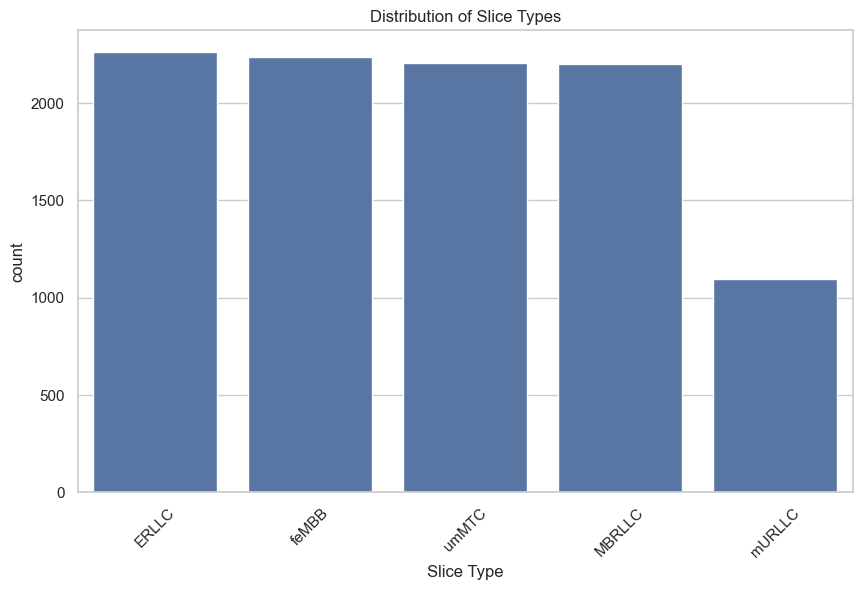

In [ ]:
# Visualization
plt.figure(figsize=(10, 6))
sns.countplot(x="Slice Type", data=df, order=df["Slice Type"].value_counts().index)
plt.title("Distribution of Slice Types")
plt.xticks(rotation=45)
plt.show()

## STEP 5 — Use Case Type Analysis

In [ ]:
# Check use case distribution
use_case_counts = df["Use Case Type"].value_counts()
print("Use Case Type Distribution:")
print(use_case_counts)
print("\nPercentage Distribution:")
print(df["Use Case Type"].value_counts(normalize=True) * 100)

Use Case Type Distribution:
Use Case Type
3D/UHD Video                1152
Servo motors                1133
Motion control              1129
Smart Home                  1119
V2X                         1115
Remote health monitoring    1094
Delivery drones             1088
Smart City                  1085
VR/AR                       1085
Name: count, dtype: int64

Percentage Distribution:
Use Case Type
3D/UHD Video                11.52
Servo motors                11.33
Motion control              11.29
Smart Home                  11.19
V2X                         11.15
Remote health monitoring    10.94
Delivery drones             10.88
Smart City                  10.85
VR/AR                       10.85
Name: proportion, dtype: float64


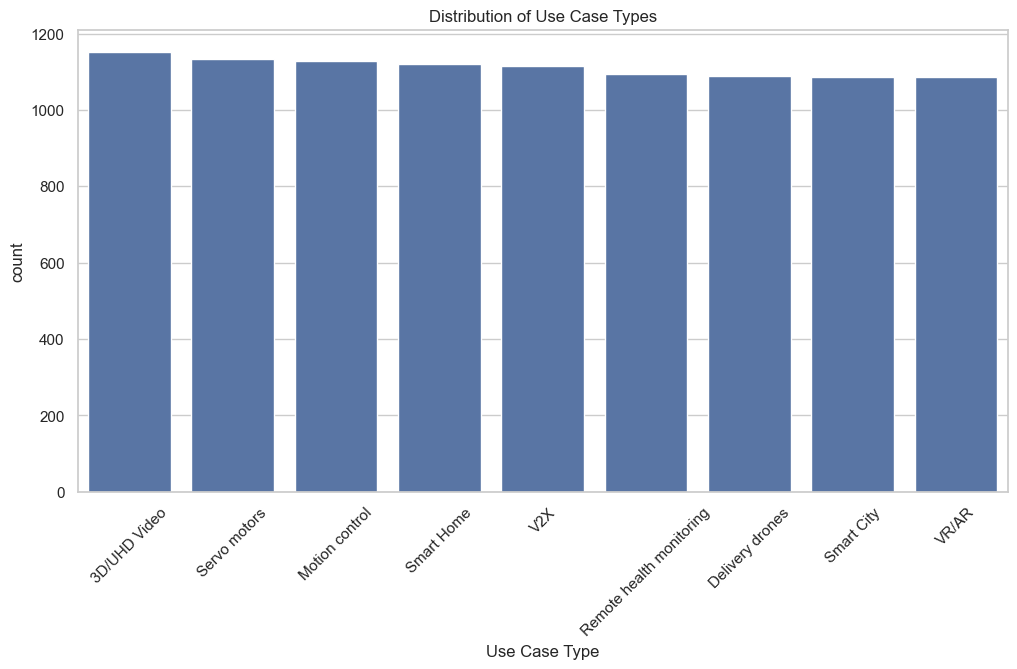

In [ ]:
# Visualization
plt.figure(figsize=(12, 6))
sns.countplot(x="Use Case Type", data=df, order=df["Use Case Type"].value_counts().index)
plt.title("Distribution of Use Case Types")
plt.xticks(rotation=45)
plt.show()

## STEP 6 — Descriptive Statistics

In [ ]:
# Numerical columns statistics
numerical_cols = df.select_dtypes(include=[np.number]).columns
print("Numerical Columns:", numerical_cols.tolist())
df[numerical_cols].describe()

Numerical Columns: ['Latency Budget (ns)', 'Jitter Budget (ns)', 'Data Rate Budget (Gbps)', 'Slice Available Transfer Rate (Gbps)', 'Slice Latency (ns)', 'Slice Packet Loss', 'Slice Jitter (ns)']


,Latency Budget (ns),Jitter Budget (ns),Data Rate Budget (Gbps),Slice Available Transfer Rate (Gbps),Slice Latency (ns),Slice Packet Loss,Slice Jitter (ns)
count,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,1.000000e+04
mean,329824.230000,113013.300000,223.700000,4991.432693,2.004804e+06,0.000500,2.011296e+06
std,470040.620751,316446.079349,416.744139,1658.361476,6.617056e+05,0.000165,6.698197e+05
min,0.000000,0.000000,0.000000,1.000000,1.000000e+00,0.000000,1.000000e+00
25%,0.000000,0.000000,0.000000,3865.775465,1.552413e+06,0.000389,1.562456e+06
50%,100.000000,0.000000,0.000000,4996.070733,2.008105e+06,0.000498,2.005906e+06
75%,1000000.000000,0.000000,0.000000,6113.292873,2.459038e+06,0.000610,2.460944e+06
max,1000000.000000,1000000.000000,1000.000000,10000.000000,4.000000e+06,0.001000,4.000000e+06


## STEP 7 — Missing Values Check

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

Missing values per column:
Use Case Type                           0
Packet Loss Budget                      0
Latency Budget (ns)                     0
Jitter Budget (ns)                      0
Data Rate Budget (Gbps)                 0
Required Mobility                       0
Required Connectivity                   0
Slice Available Transfer Rate (Gbps)    0
Slice Latency (ns)                      0
Slice Packet Loss                       0
Slice Jitter (ns)                       0
Slice Type                              0
Slice Handover                          0
dtype: int64

Total missing values: 0


## STEP 8 — Duplicate Rows

In [ ]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Dataset shape after removing duplicates: {df.shape}")

Number of duplicate rows: 0


## STEP 9 — Feature Distributions (Univariate Analysis)

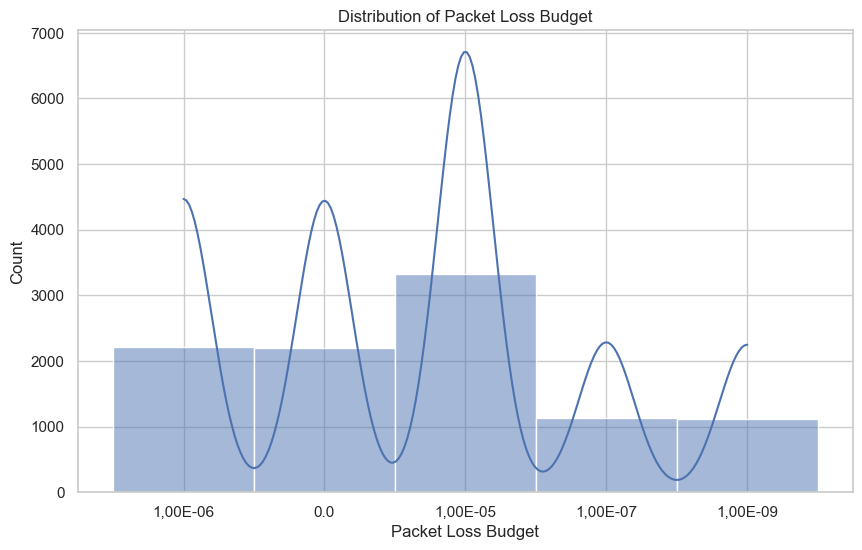

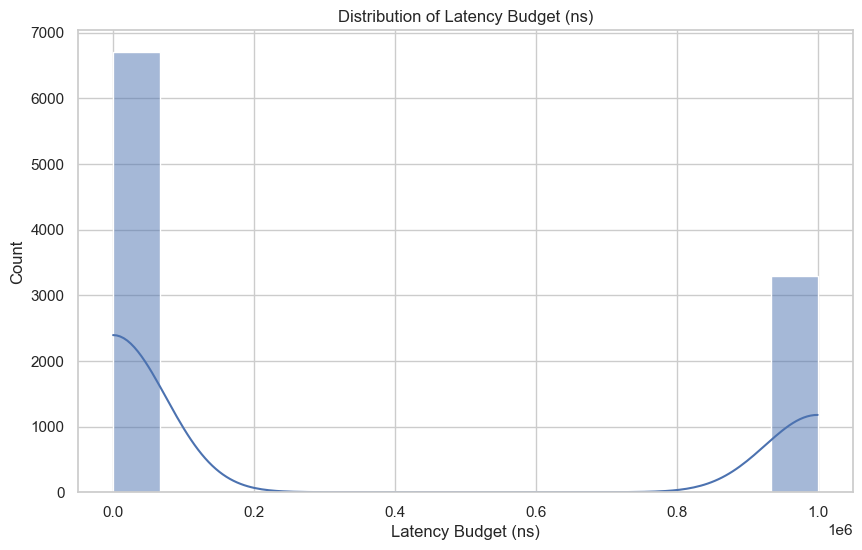

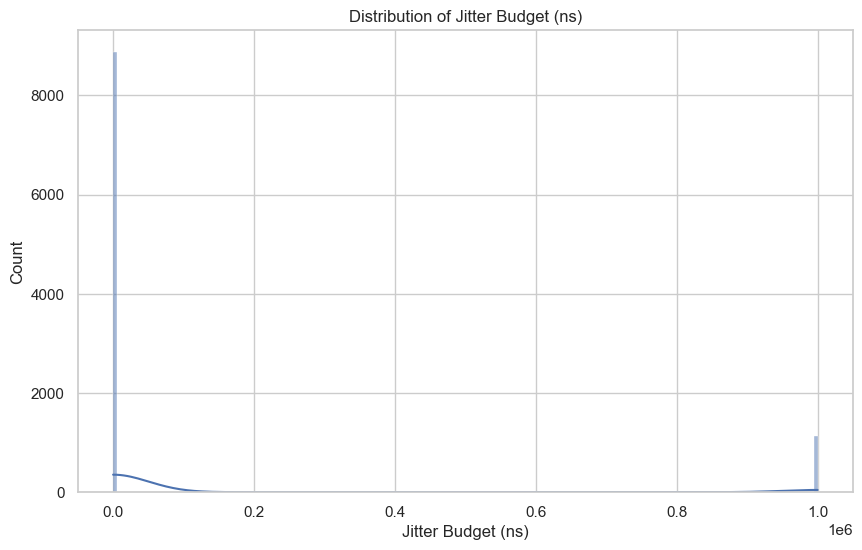

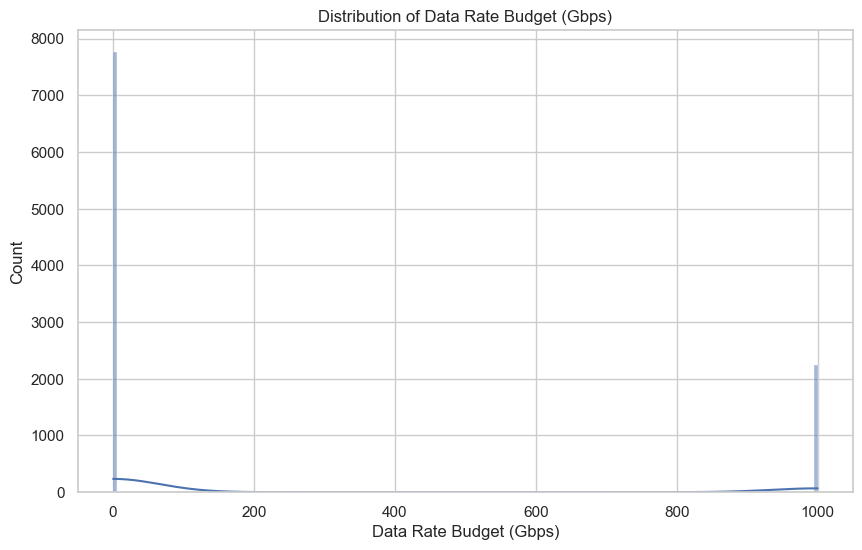

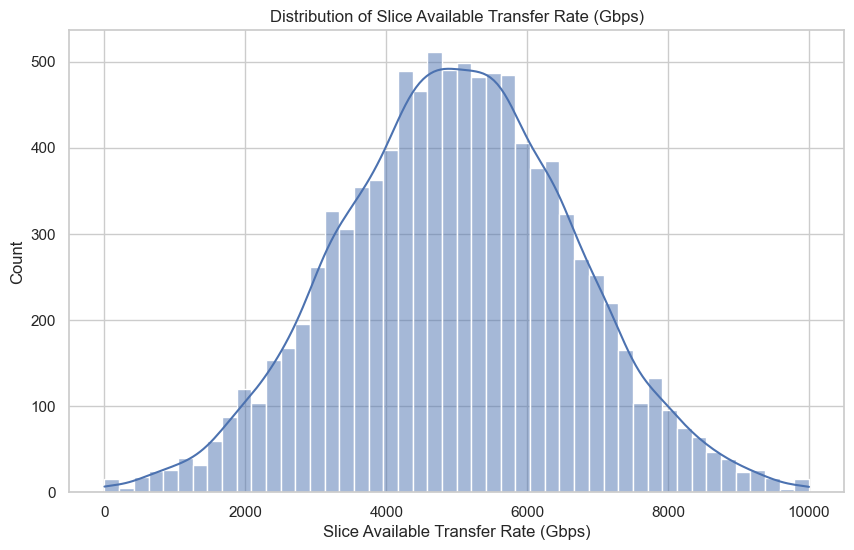

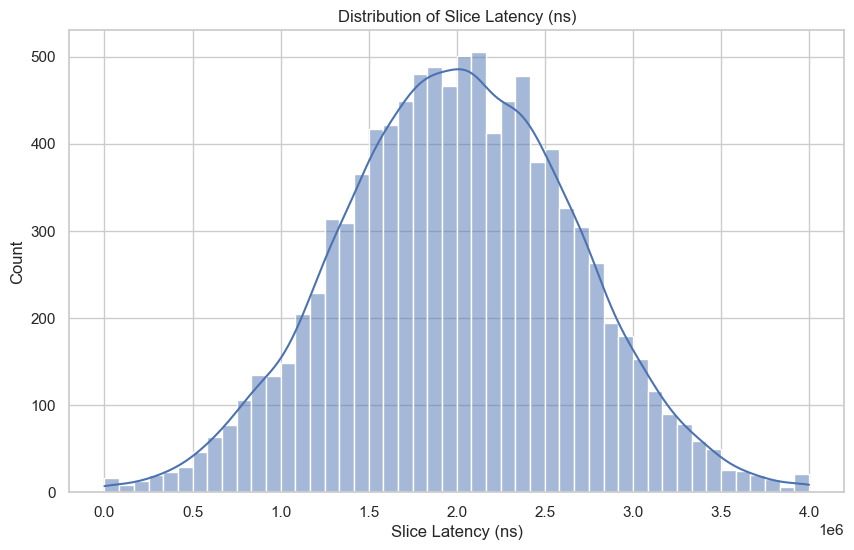

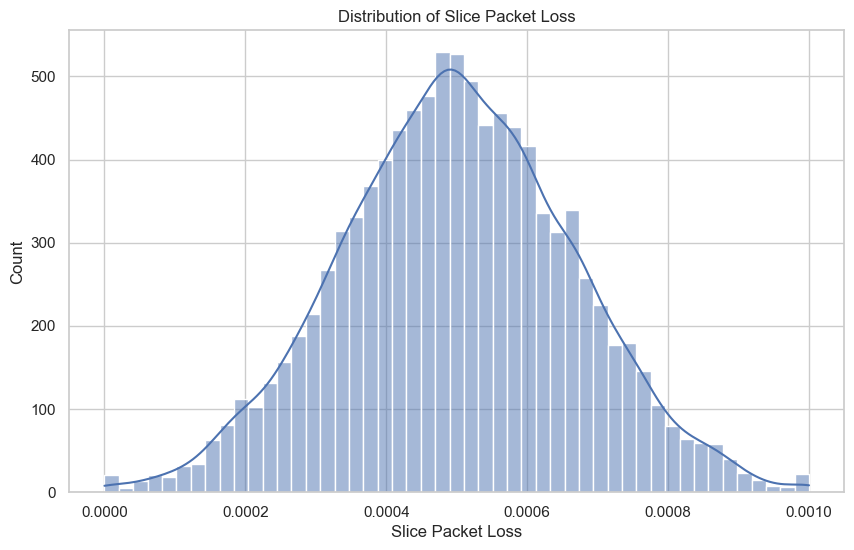

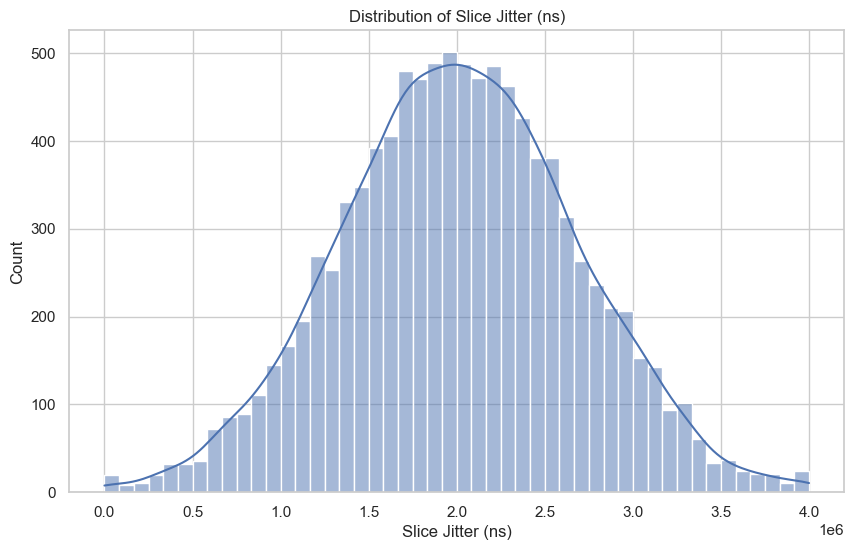

In [ ]:
# Plot distributions for key numerical features
key_features = [
    "Packet Loss Budget", "Latency Budget (ns)", "Jitter Budget (ns)", 
    "Data Rate Budget (Gbps)", "Slice Available Transfer Rate (Gbps)",
    "Slice Latency (ns)", "Slice Packet Loss", "Slice Jitter (ns)"
]

for col in key_features:
    if col in df.columns:
        plt.figure(figsize=(10, 6))
        sns.histplot(df[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()

## STEP 10 — Categorical Features Analysis

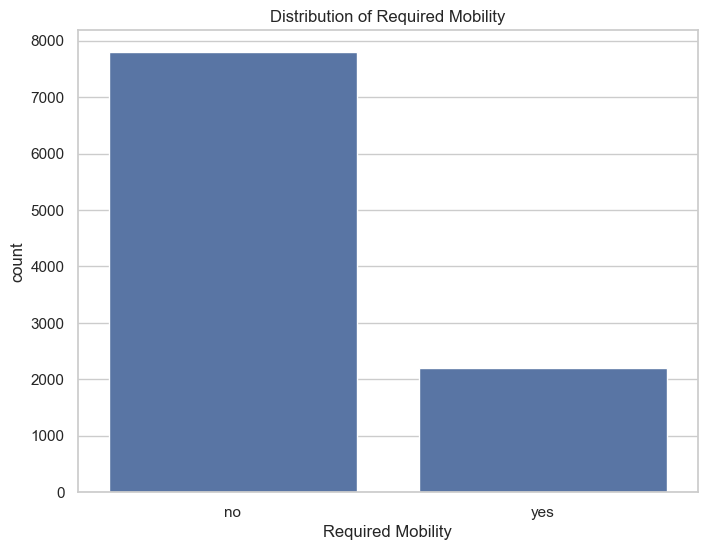

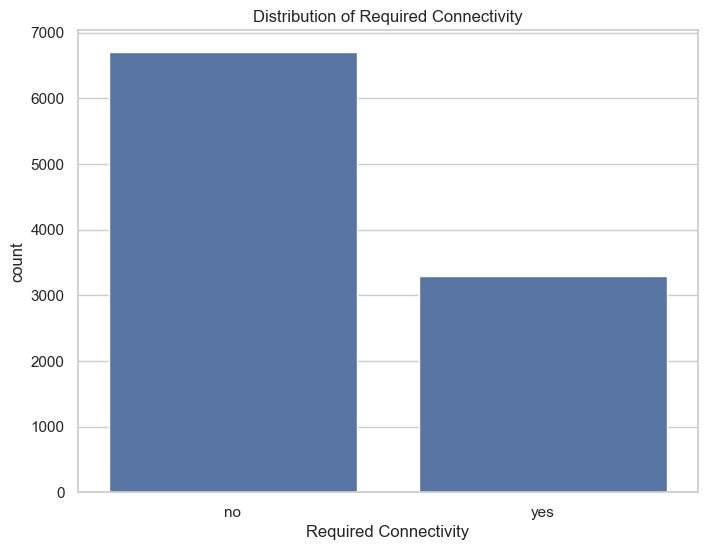

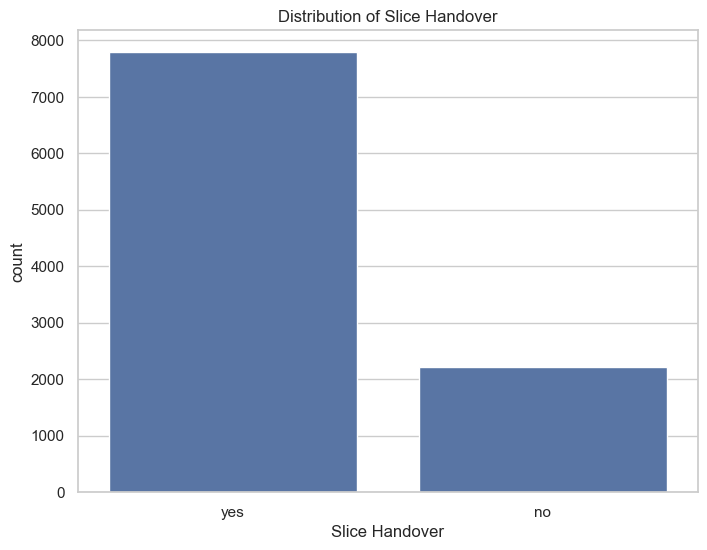

In [ ]:
# Analyze categorical features
categorical_features = ["Required Mobility", "Required Connectivity", "Slice Handover"]

for col in categorical_features:
    if col in df.columns:
        plt.figure(figsize=(8, 6))
        sns.countplot(x=col, data=df)
        plt.title(f"Distribution of {col}")
        plt.show()

## STEP 11 — Correlation Analysis

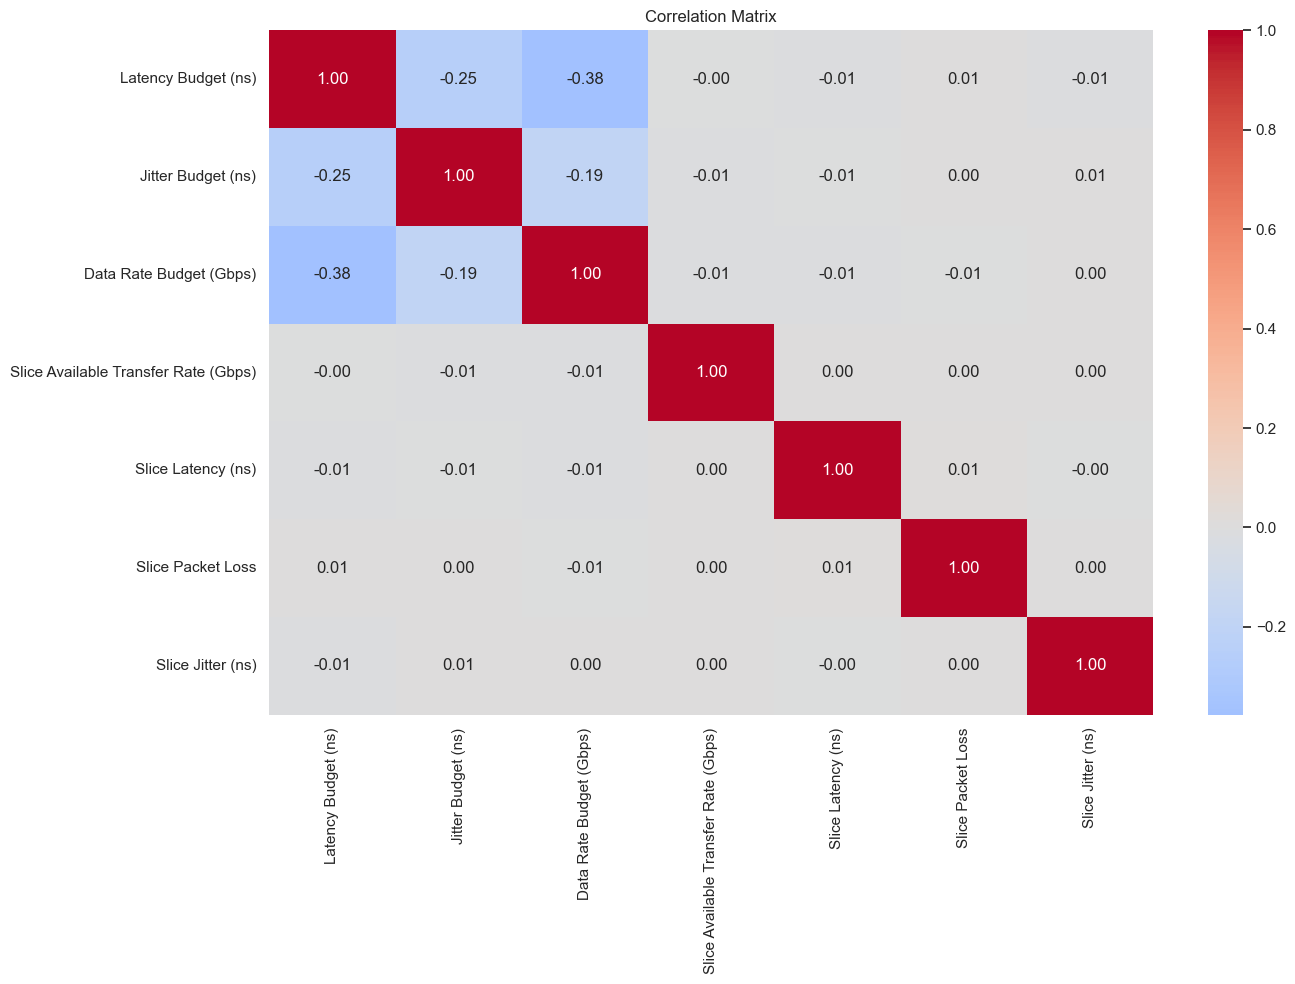

In [ ]:
# Correlation matrix for numerical features
numerical_df = df.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt='.2f', center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## STEP 12 — Feature vs Target Analysis

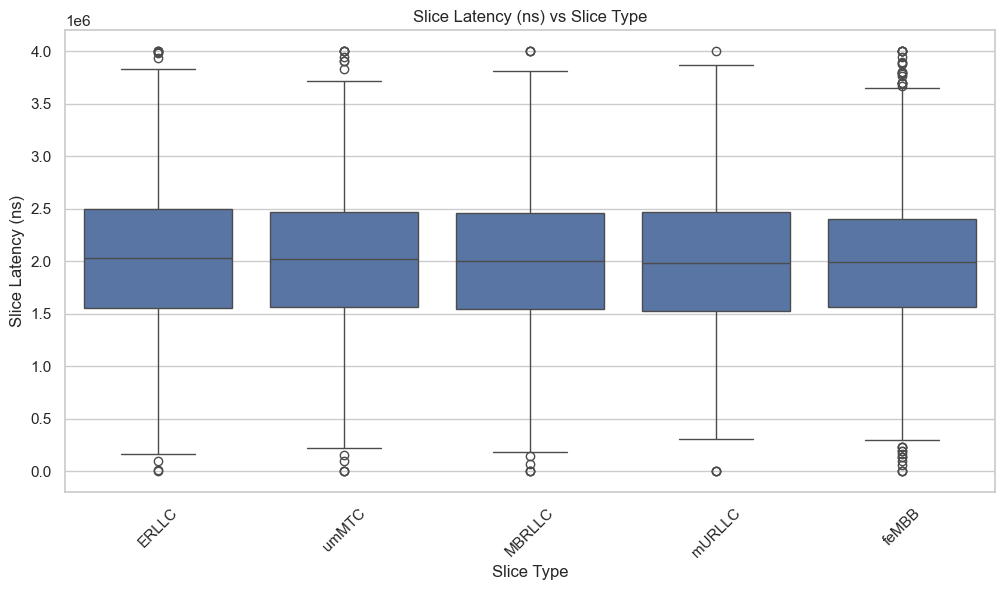

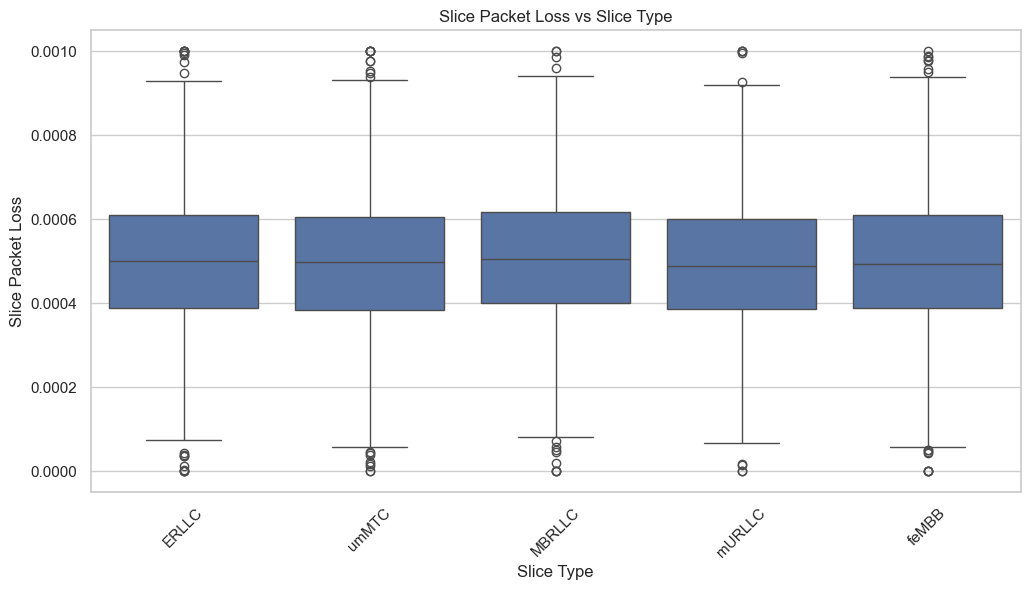

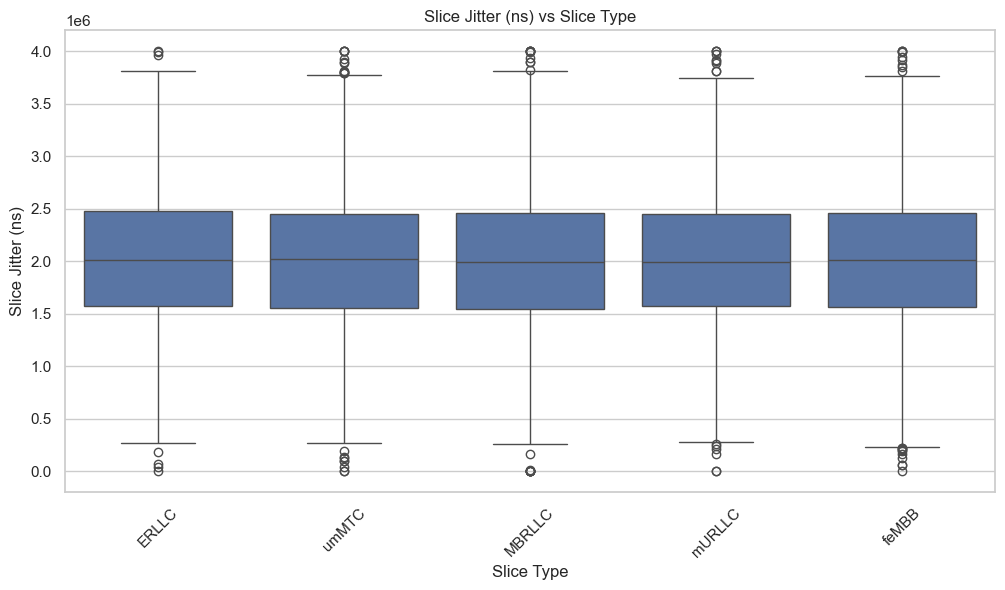

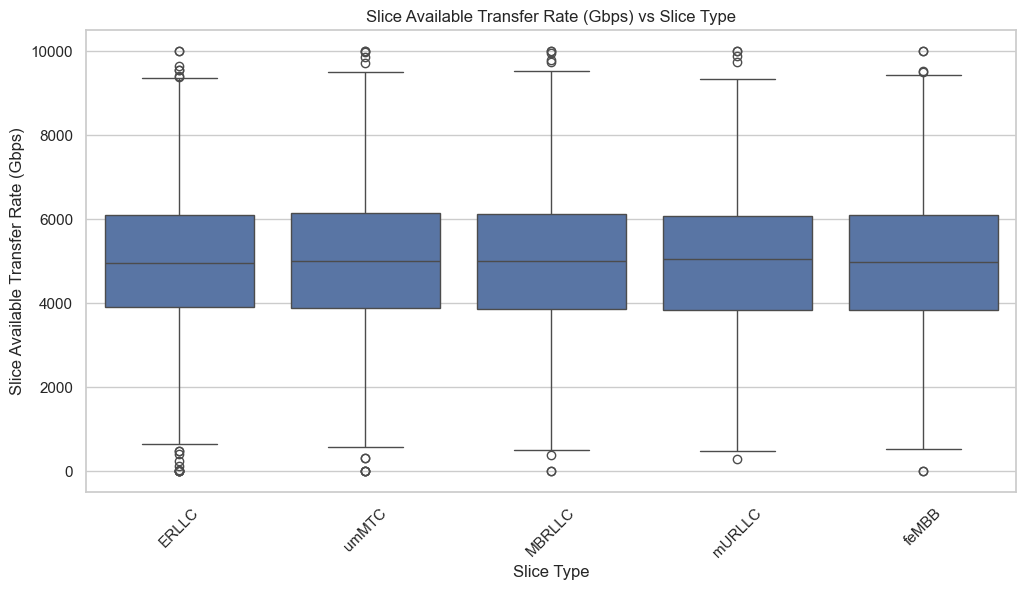

In [ ]:
# Slice Type vs Key Features
key_numerical_features = ["Slice Latency (ns)", "Slice Packet Loss", "Slice Jitter (ns)", "Slice Available Transfer Rate (Gbps)"]

for col in key_numerical_features:
    if col in df.columns:
        plt.figure(figsize=(12, 6))
        sns.boxplot(x="Slice Type", y=col, data=df)
        plt.title(f"{col} vs Slice Type")
        plt.xticks(rotation=45)
        plt.show()

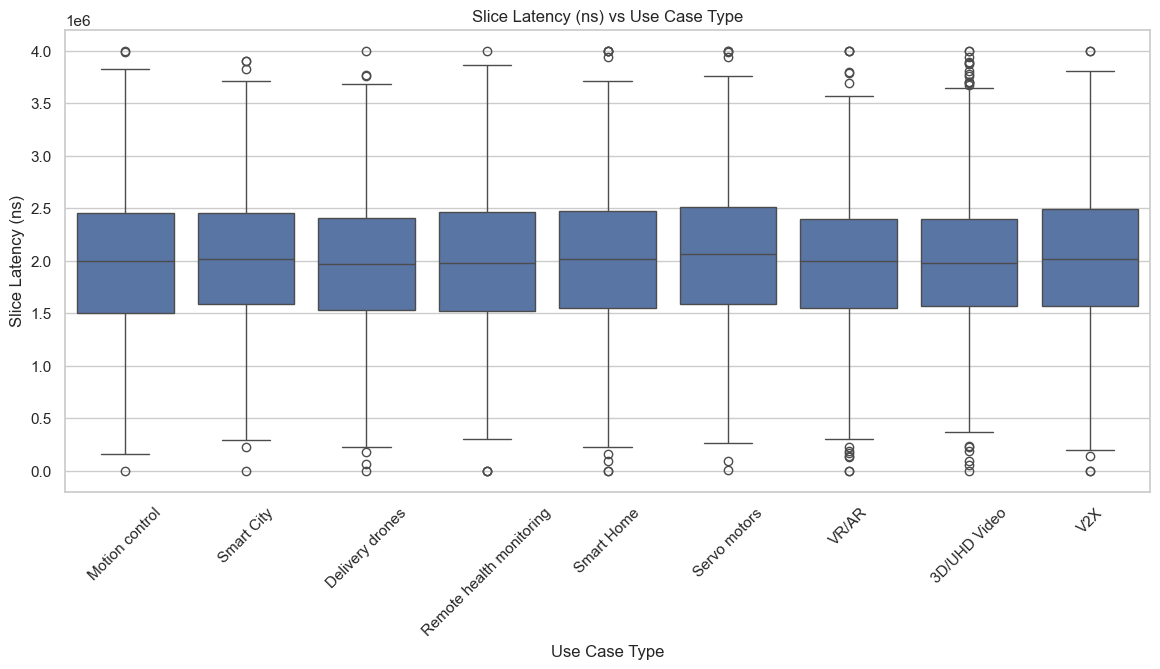

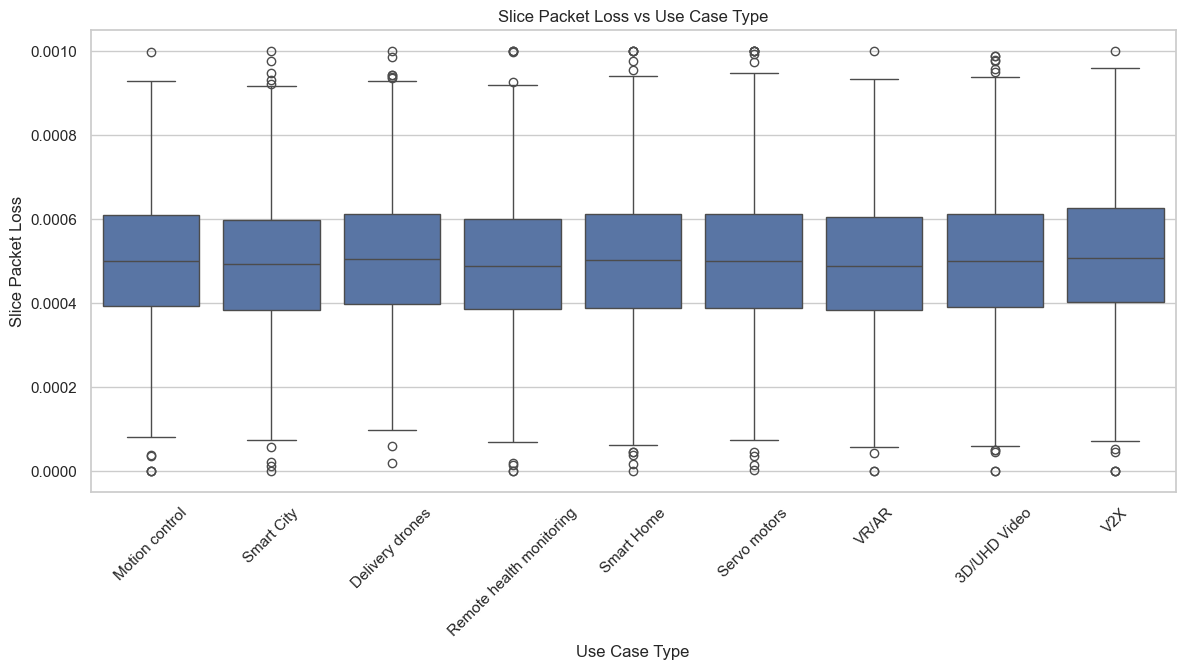

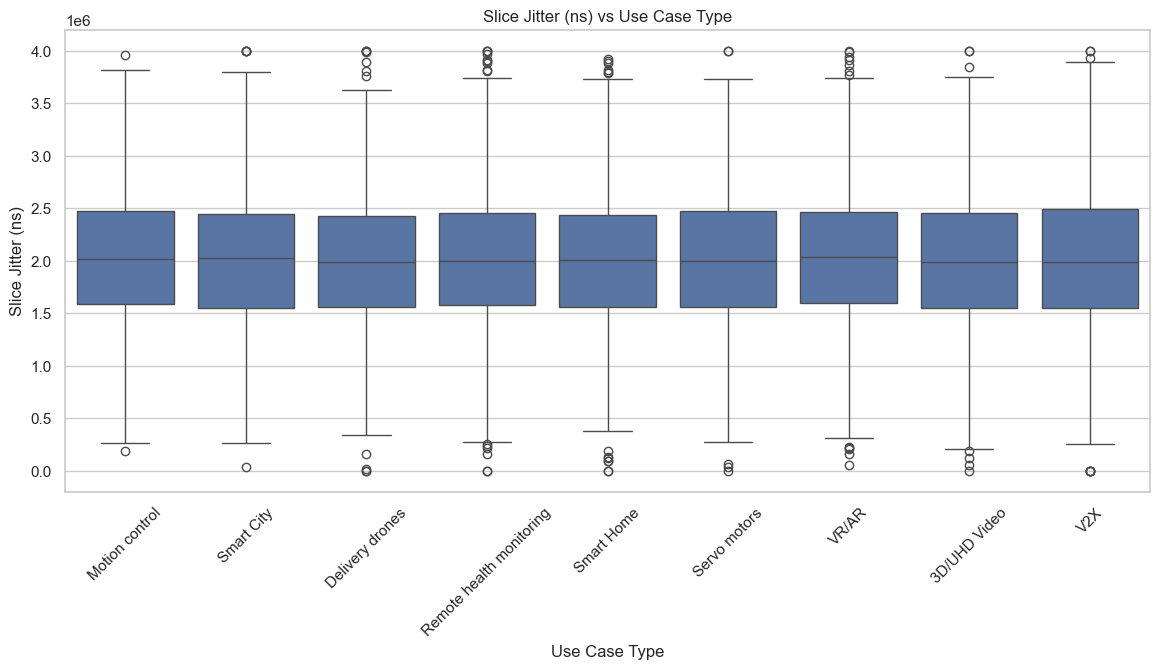

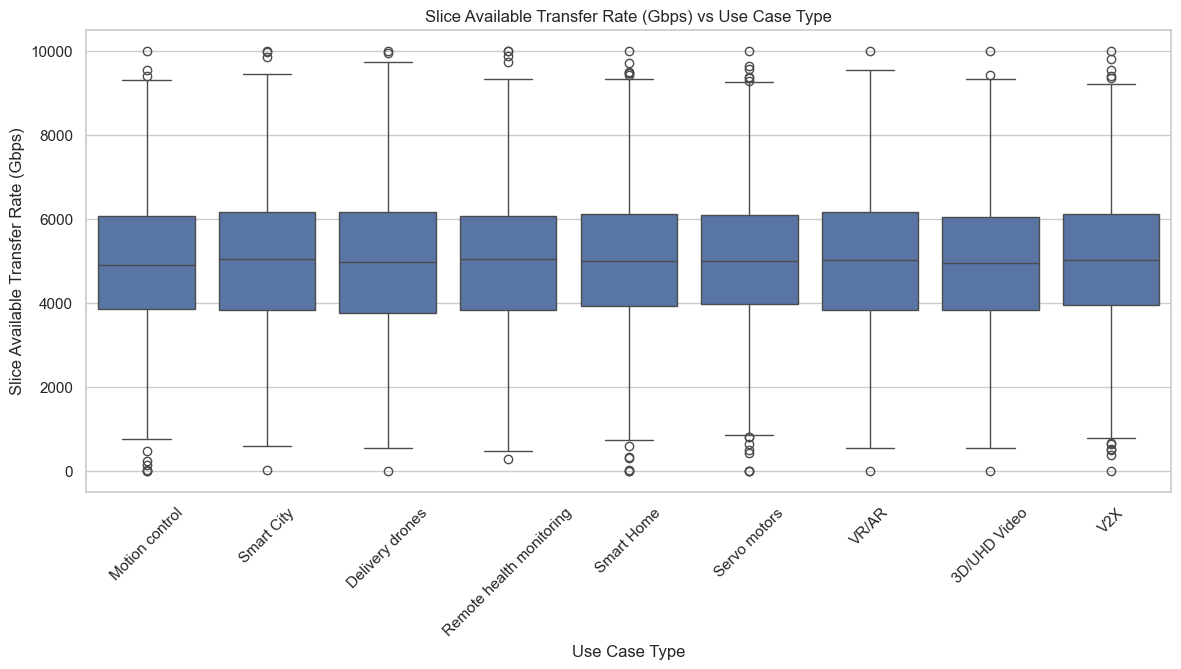

In [ ]:
# Use Case Type vs Key Features
for col in key_numerical_features:
    if col in df.columns:
        plt.figure(figsize=(14, 6))
        sns.boxplot(x="Use Case Type", y=col, data=df)
        plt.title(f"{col} vs Use Case Type")
        plt.xticks(rotation=45)
        plt.show()

## STEP 13 — Outlier Detection

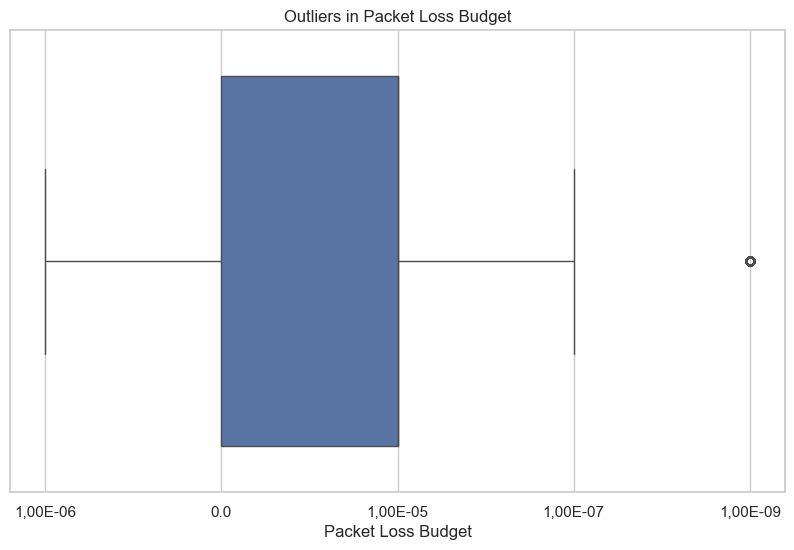

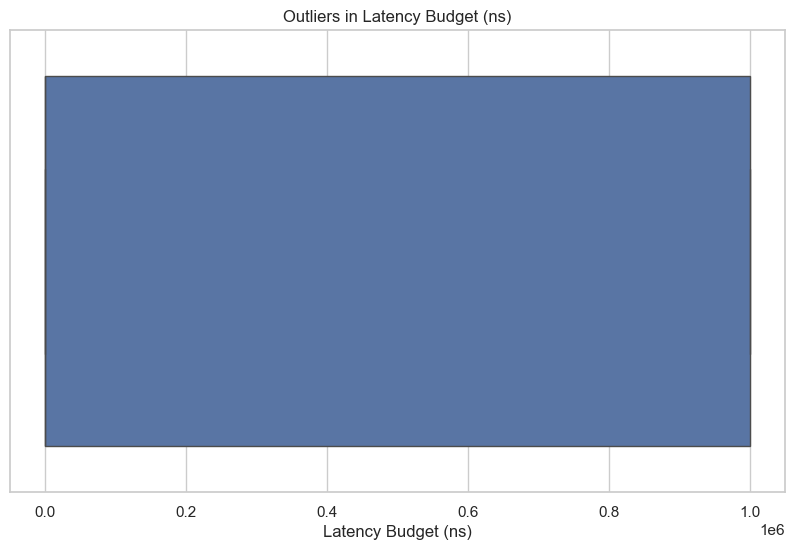

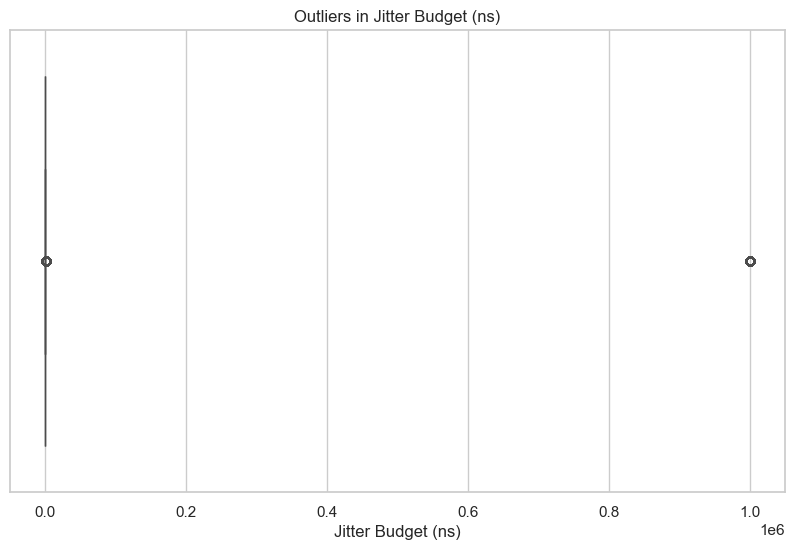

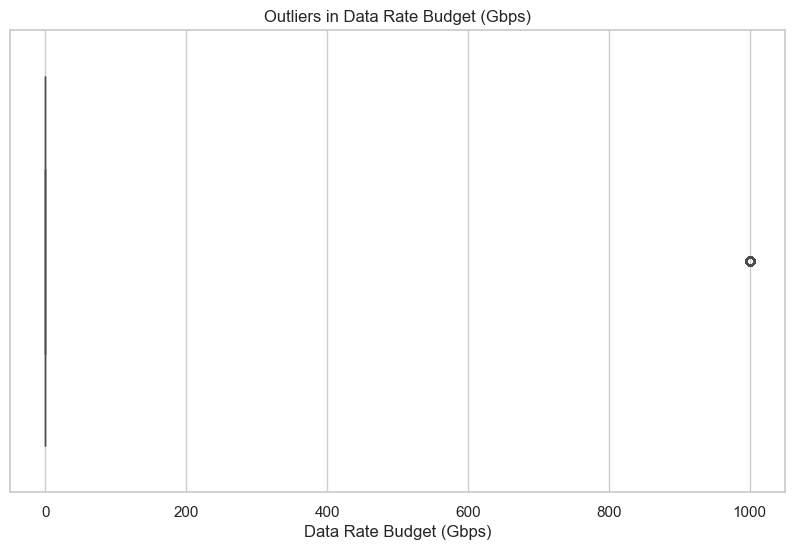

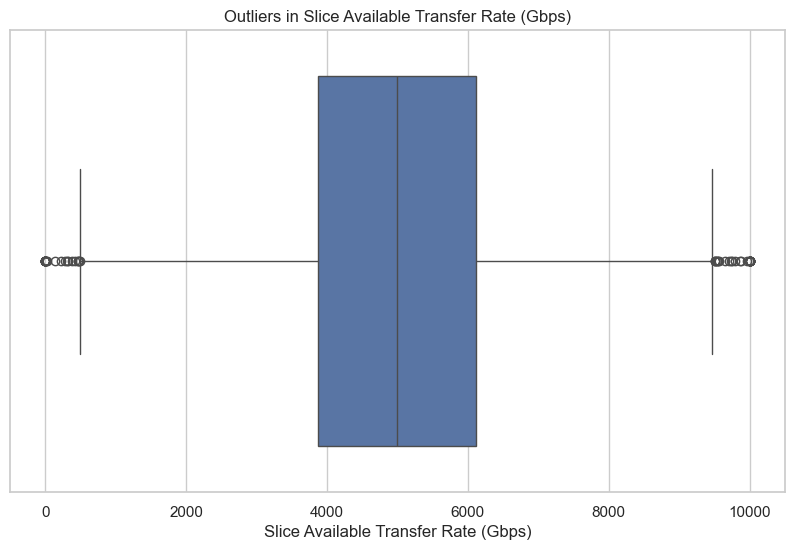

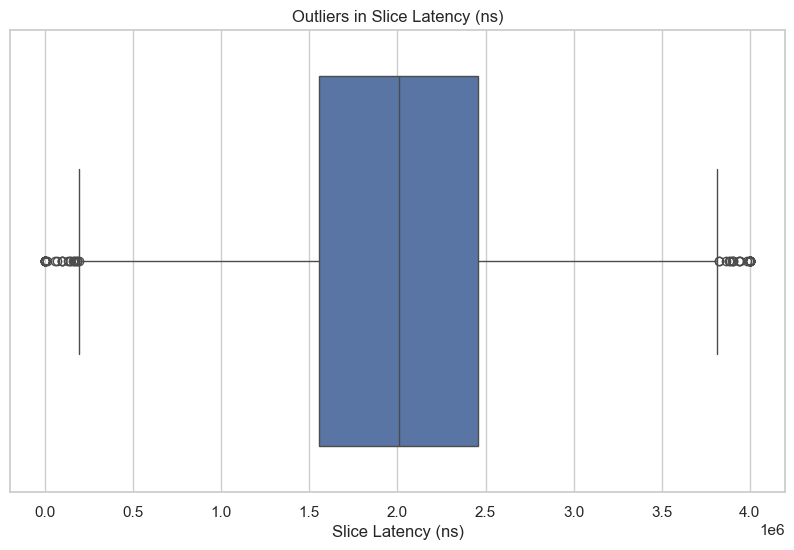

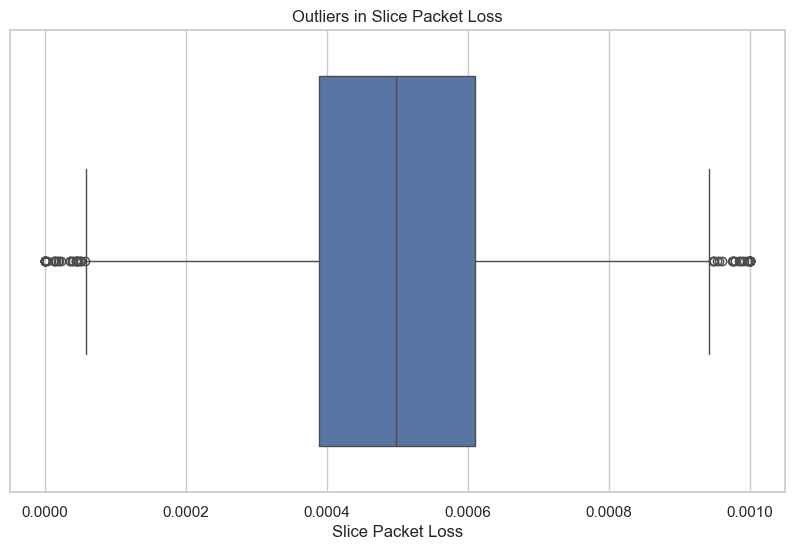

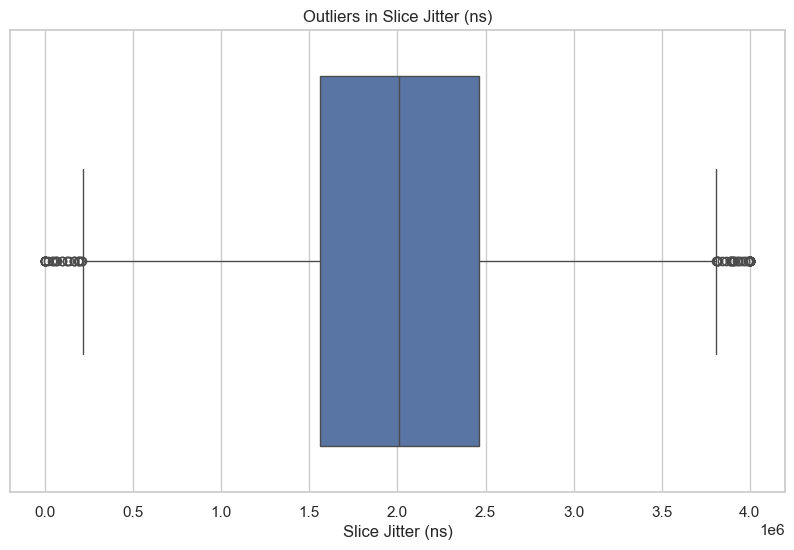

In [ ]:
# Detect outliers in numerical features
for col in key_features:
    if col in df.columns:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=df[col])
        plt.title(f"Outliers in {col}")
        plt.show()

## STEP 14 — Cross-tabulation Analysis

Use Case Type vs Slice Type:
Slice Type                ERLLC  MBRLLC  feMBB  mURLLC  umMTC
Use Case Type                                                
3D/UHD Video                  0       0   1152       0      0
Delivery drones               0    1088      0       0      0
Motion control             1129       0      0       0      0
Remote health monitoring      0       0      0    1094      0
Servo motors               1133       0      0       0      0
Smart City                    0       0      0       0   1085
Smart Home                    0       0      0       0   1119
V2X                           0    1115      0       0      0
VR/AR                         0       0   1085       0      0


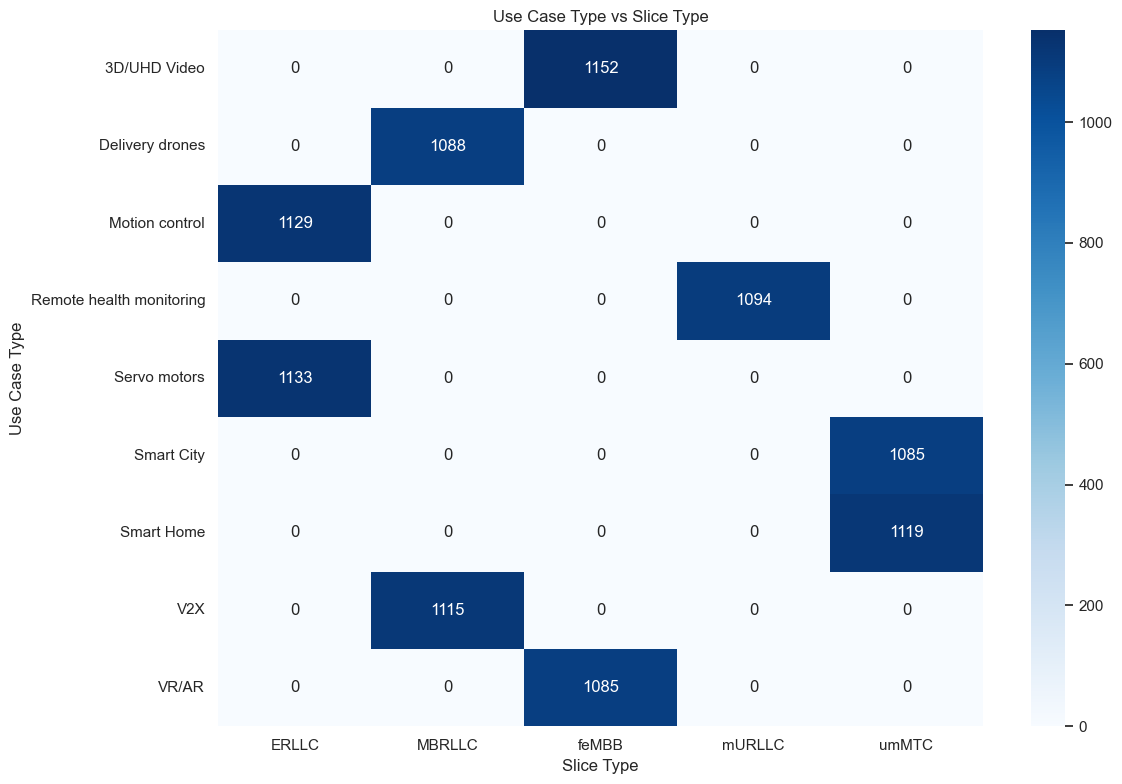

In [ ]:
# Cross-tabulation between categorical variables
print("Use Case Type vs Slice Type:")
cross_tab = pd.crosstab(df["Use Case Type"], df["Slice Type"])
print(cross_tab)

# Visualize the cross-tabulation
plt.figure(figsize=(12, 8))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title("Use Case Type vs Slice Type")
plt.tight_layout()
plt.show()


Required Mobility vs Slice Type:
Slice Type         ERLLC  MBRLLC  feMBB  mURLLC  umMTC
Required Mobility                                     
no                  2262       0   2237    1094   2204
yes                    0    2203      0       0      0


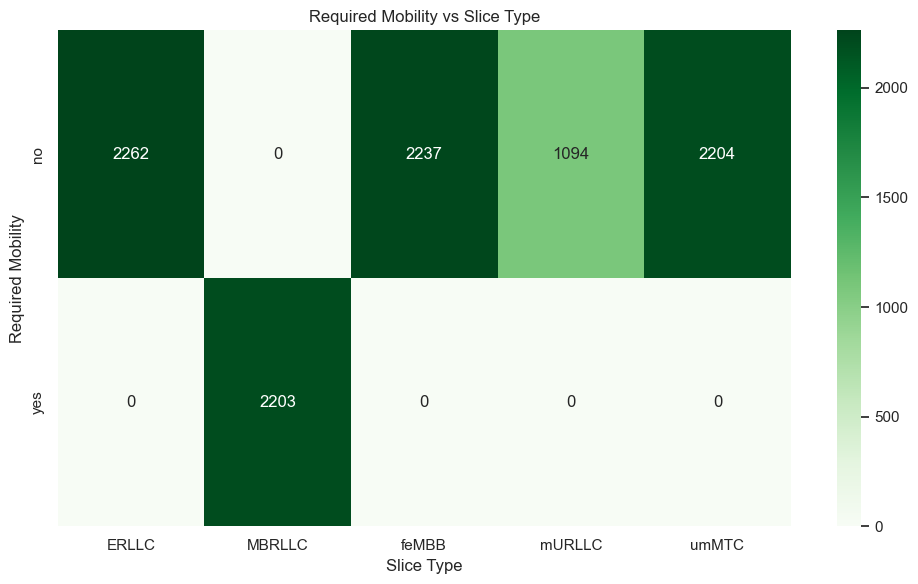

In [ ]:
# Required Mobility vs Slice Type
print("\nRequired Mobility vs Slice Type:")
mobility_cross = pd.crosstab(df["Required Mobility"], df["Slice Type"])
print(mobility_cross)

plt.figure(figsize=(10, 6))
sns.heatmap(mobility_cross, annot=True, fmt='d', cmap='Greens')
plt.title("Required Mobility vs Slice Type")
plt.tight_layout()
plt.show()

## STEP 15 — Summary Statistics by Slice Type

In [ ]:
# Group by slice type and calculate statistics
slice_stats = df.groupby("Slice Type")[numerical_cols].agg(['mean', 'std', 'min', 'max'])
print("Summary Statistics by Slice Type:")
display(slice_stats)

Summary Statistics by Slice Type:


Latency Budget (ns)                                \
                          mean         std      min      max   
Slice Type                                                     
ERLLC               549.204244  450.098799      100     1000   
MBRLLC          1000000.000000    0.000000  1000000  1000000   
feMBB                 0.000000    0.000000        0        0   
mURLLC          1000000.000000    0.000000  1000000  1000000   
umMTC                 0.000000    0.000000        0        0   

           Jitter Budget (ns)                                \
                         mean            std   min      max   
Slice Type                                                    
ERLLC           499616.710875  499609.666609  1000  1000000   
MBRLLC               0.000000       0.000000     0        0   
feMBB                0.000000       0.000000     0        0   
mURLLC               0.000000       0.000000     0        0   
umMTC                0.000000       0.000000     0        0   

           Data Rate Budget (Gbps)                   \
                              mean  std   min   max   
Slice Type                                            
ERLLC                          0.0  0.0     0     0   
MBRLLC                         0.0  0.0     0     0   
feMBB                       1000.0  0.0  1000  1000   
mURLLC                         0.0  0.0     0     0   
umMTC                          0.0  0.0     0     0   

           Slice Available Transfer Rate (Gbps)                           \
                                           mean          std         min   
Slice Type                                                                 
ERLLC                               4996.791481  1650.414833    1.000000   
MBRLLC                              4979.431717  1664.686011    1.000000   
feMBB                               4969.092081  1648.715662    1.000000   
mURLLC                              4999.105313  1688.032249  278.822339   
umMTC                               5016.795066  1656.169453    1.000000   

                    Slice Latency (ns)                                 \
                max               mean            std  min        max   
Slice Type                                                              
ERLLC       10000.0       2.022298e+06  666432.036250  1.0  4000000.0   
MBRLLC      10000.0       1.992372e+06  656109.189177  1.0  4000000.0   
feMBB       10000.0       1.996112e+06  657756.961496  1.0  4000000.0   
mURLLC      10000.0       1.996894e+06  661216.547792  1.0  4000000.0   
umMTC       10000.0       2.012026e+06  666752.523488  1.0  4000000.0   

           Slice Packet Loss                       Slice Jitter (ns)  \
                        mean       std  min    max              mean   
Slice Type                                                             
ERLLC               0.000501  0.000165  0.0  0.001      2.020621e+06   
MBRLLC              0.000506  0.000166  0.0  0.001      2.001018e+06   
feMBB               0.000498  0.000168  0.0  0.001      2.011711e+06   
mURLLC              0.000492  0.000164  0.0  0.001      2.009983e+06   
umMTC               0.000498  0.000164  0.0  0.001      2.012230e+06   

                                           
                      std  min        max  
Slice Type                                 
ERLLC       666011.055752  1.0  4000000.0  
MBRLLC      671072.735874  1.0  4000000.0  
feMBB       671964.686023  1.0  4000000.0  
mURLLC      668807.095865  1.0  4000000.0  
umMTC       671244.758472  1.0  4000000.0

## STEP 16 — Summary Statistics by Use Case Type

In [ ]:
# Group by use case type and calculate statistics
use_case_stats = df.groupby("Use Case Type")[numerical_cols].agg(['mean', 'std', 'min', 'max'])
print("Summary Statistics by Use Case Type:")
display(use_case_stats)

Summary Statistics by Use Case Type:


Latency Budget (ns)                         \
                                        mean  std      min      max   
Use Case Type                                                         
3D/UHD Video                             0.0  0.0        0        0   
Delivery drones                    1000000.0  0.0  1000000  1000000   
Motion control                        1000.0  0.0     1000     1000   
Remote health monitoring           1000000.0  0.0  1000000  1000000   
Servo motors                           100.0  0.0      100      100   
Smart City                               0.0  0.0        0        0   
Smart Home                               0.0  0.0        0        0   
V2X                                1000000.0  0.0  1000000  1000000   
VR/AR                                    0.0  0.0        0        0   

                         Jitter Budget (ns)                         \
                                       mean  std      min      max   
Use Case Type                                                        
3D/UHD Video                            0.0  0.0        0        0   
Delivery drones                         0.0  0.0        0        0   
Motion control                    1000000.0  0.0  1000000  1000000   
Remote health monitoring                0.0  0.0        0        0   
Servo motors                         1000.0  0.0     1000     1000   
Smart City                              0.0  0.0        0        0   
Smart Home                              0.0  0.0        0        0   
V2X                                     0.0  0.0        0        0   
VR/AR                                   0.0  0.0        0        0   

                         Data Rate Budget (Gbps)                   \
                                            mean  std   min   max   
Use Case Type                                                       
3D/UHD Video                              1000.0  0.0  1000  1000   
Delivery drones                              0.0  0.0     0     0   
Motion control                               0.0  0.0     0     0   
Remote health monitoring                     0.0  0.0     0     0   
Servo motors                                 0.0  0.0     0     0   
Smart City                                   0.0  0.0     0     0   
Smart Home                                   0.0  0.0     0     0   
V2X                                          0.0  0.0     0     0   
VR/AR                                     1000.0  0.0  1000  1000   

                         Slice Available Transfer Rate (Gbps)               \
                                                         mean          std   
Use Case Type                                                                
3D/UHD Video                                      4936.028833  1612.854092   
Delivery drones                                   4935.334988  1697.317230   
Motion control                                    4955.426294  1646.249837   
Remote health monitoring                          4999.105313  1688.032249   
Servo motors                                      5038.010630  1654.252211   
Smart City                                        5007.390626  1657.459380   
Smart Home                                        5025.913759  1655.607818   
V2X                                               5022.460632  1631.829496   
VR/AR                                             5004.197023  1685.992321   

                                              Slice Latency (ns)  \
                                 min      max               mean   
Use Case Type                                                      
3D/UHD Video                1.000000  10000.0       2.010098e+06   
Delivery drones             1.000000  10000.0       1.971361e+06   
Motion control              1.000000  10000.0       1.995114e+06   
Remote health monitoring  278.822339  10000.0       1.996894e+06   
Servo motors                1.000000  10000.0       2.049386e+06   
Smart City           

## STEP 17 — Data Quality Summary

In [ ]:
print("=== DATASET QUALITY SUMMARY ===")
print(f"Dataset shape: {df.shape}")
print(f"Number of features: {df.shape[1]}")
print(f"Number of samples: {df.shape[0]}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Number of slice types: {df['Slice Type'].nunique()}")
print(f"Number of use case types: {df['Use Case Type'].nunique()}")
print(f"Slice types: {df['Slice Type'].unique().tolist()}")
print(f"Use case types: {df['Use Case Type'].unique().tolist()}")

=== DATASET QUALITY SUMMARY ===
Dataset shape: (10000, 13)
Number of features: 13
Number of samples: 10000
Missing values: 0
Duplicate rows: 0
Number of slice types: 5
Number of use case types: 9
Slice types: ['ERLLC', 'umMTC', 'MBRLLC', 'mURLLC', 'feMBB']
Use case types: ['Motion control', 'Smart City', 'Delivery drones', 'Remote health monitoring', 'Smart Home', 'Servo motors', 'VR/AR', '3D/UHD Video', 'V2X']


## CONCLUSION

This notebook provides a comprehensive analysis of the network slicing dataset v3, including:
- Data loading and initial exploration
- Target variable analysis (Slice Type)
- Use case type analysis
- Statistical summaries and distributions
- Correlation analysis
- Feature vs target relationships
- Outlier detection
- Cross-tabulation analysis
- Data quality assessment

The analysis follows the same structured approach as project1.ipynb but is adapted for the different schema and characteristics of dataset 3.